 Extracting longitudinal radiomic sequences...
 Building integrated VHT Patient objects...
 Converting Longitudinal Kinetics into VHT Behavioral Features...


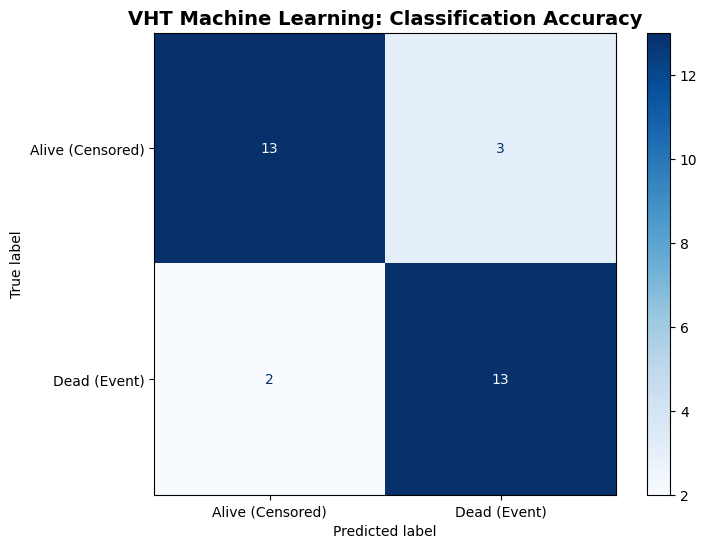

 VHT Matrix Complete: 46 components explain 99% variance.

 TOP DRIVERS OF VHT SIGNATURE (PC1):
Index(['Cycle length of Additional Therapy (q days)', 'Number of Fractions',
       'Number of Days from Diagnosis to Starting Additional Therapy ',
       'Number of days from Diagnosis to date of Further Progression',
       'Number of Days from Diagnosis to Starting 2nd_Additional Therapy ',
       'Number of Days from Diagnosis to Start Immunotherapy ',
       'Multiple surgeries', 'Days from Diagnosis to new treatment',
       ' Number of days from Diagnosis to Initial Chemo Therapy end date',
       'Number of days from Diagnosis to date of First Progression'],
      dtype='object')


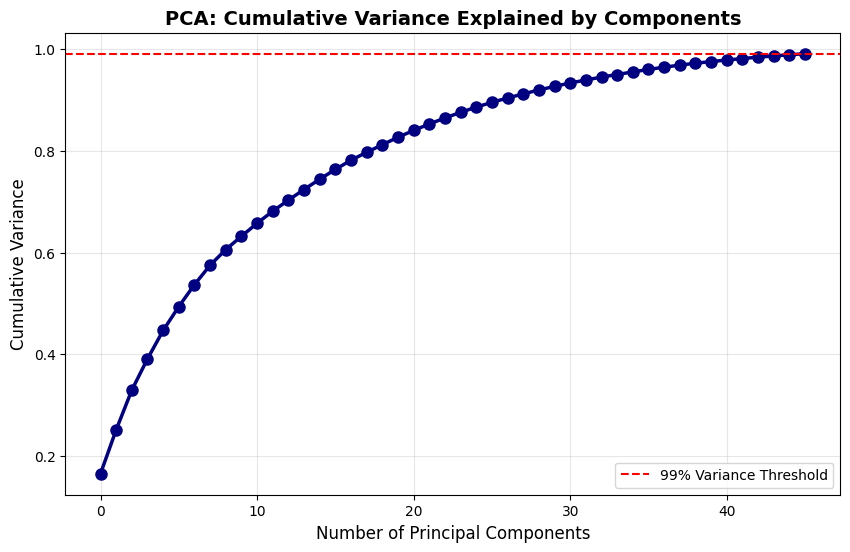

/var/folders/b9/x77syzb94gdggfcpp713pvjm0000gn/T/ipykernel_82490/3832089938.py:260: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=pc1_loadings.head(10).index, x=pc1_loadings.head(10).values, palette='viridis')


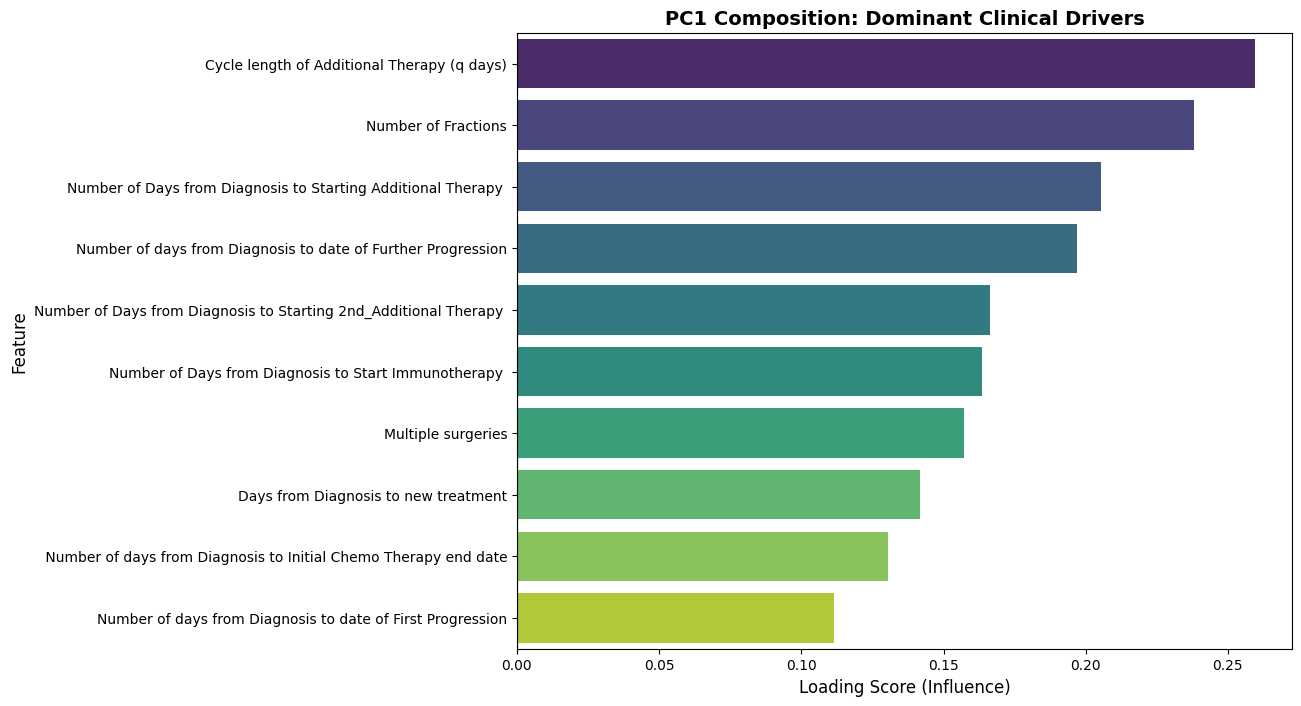

<lifelines.CoxPHFitter: fitted with 203 total observations, 106 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 203
number of events observed = 97
   partial log-likelihood = -340.22
         time fit was run = 2026-05-19 14:24:09 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
PC1       -0.20      0.82      0.04           -0.27           -0.13                0.77                0.88
PC2       -0.20      0.82      0.06           -0.31           -0.09                0.73                0.92
PC3       -0.07      0.93      0.05           -0.16            0.03                0.85                1.03
PC4        0.01      1.01      0.06           -0.11            0.13                0.89                1.14
PC5        0.06      1.06      0.05           -0.05            0.16                0.95                1.18
PC6        0.08      1.08      0.07           -0.06            0.22                0.94                1.25
PC7        0.07      1.08      0.06           -0.05            0.20                0.95                1.22
PC8        0.11      1.12      0.07           -0.02            0.24                0.98                1.27
PC9       -0.06      0.94      0.09           -0.24            0.11                0.79                1.12
PC10       0.05      1.06      0.10           -0.14            0.25                0.87                1.28
PC11       0.01      1.01      0.08           -0.16            0.17                0.85                1.19
PC12       0.14      1.15      0.10           -0.05            0.34                0.95                1.40
PC13      -0.01      0.99      0.09           -0.19            0.17                0.83                1.19
PC14      -0.08      0.92      0.11           -0.29            0.13                0.75                1.14
PC15      -0.29      0.75      0.11           -0.51           -0.07                0.60                0.93
PC16      -0.02      0.98      0.10           -0.22            0.17                0.80                1.19
PC17       0.02      1.02      0.11           -0.20            0.24                0.82                1.27
PC18       0.10      1.10      0.12           -0.13            0.32                0.88                1.38
PC19       0.25      1.28      0.12            0.02            0.48                1.02                1.62
PC20       0.10      1.10      0.13           -0.16            0.35                0.85                1.42
PC21       0.09      1.09      0.11           -0.14            0.31                0.87                1.37
PC22       0.34      1.40      0.14            0.05            0.62                1.05                1.86
PC23      -0.13      0.88      0.14           -0.40            0.15                0.67                1.16
PC24       0.17      1.19      0.15           -0.12            0.46                0.89                1.58
PC25      -0.21      0.81      0.17           -0.54            0.13                0.58                1.14
PC26       0.01      1.01      0.14           -0.27            0.29                0.76                1.33
PC27      -0.01      0.99      0.16           -0.32            0.30                0.72                1.35
PC28      -0.03      0.97      0.17           -0.35            0.29                0.70                1.34
PC29      -0.09      0.91      0.16           -0.42            0.23                0.66                1.26
PC30       0.12      1.13      0.16           -0.19            0.43                0.83                1.54
PC31      -0.51      0.60      0.20           -0.90           -0.12                0.41                0.88
PC32       0

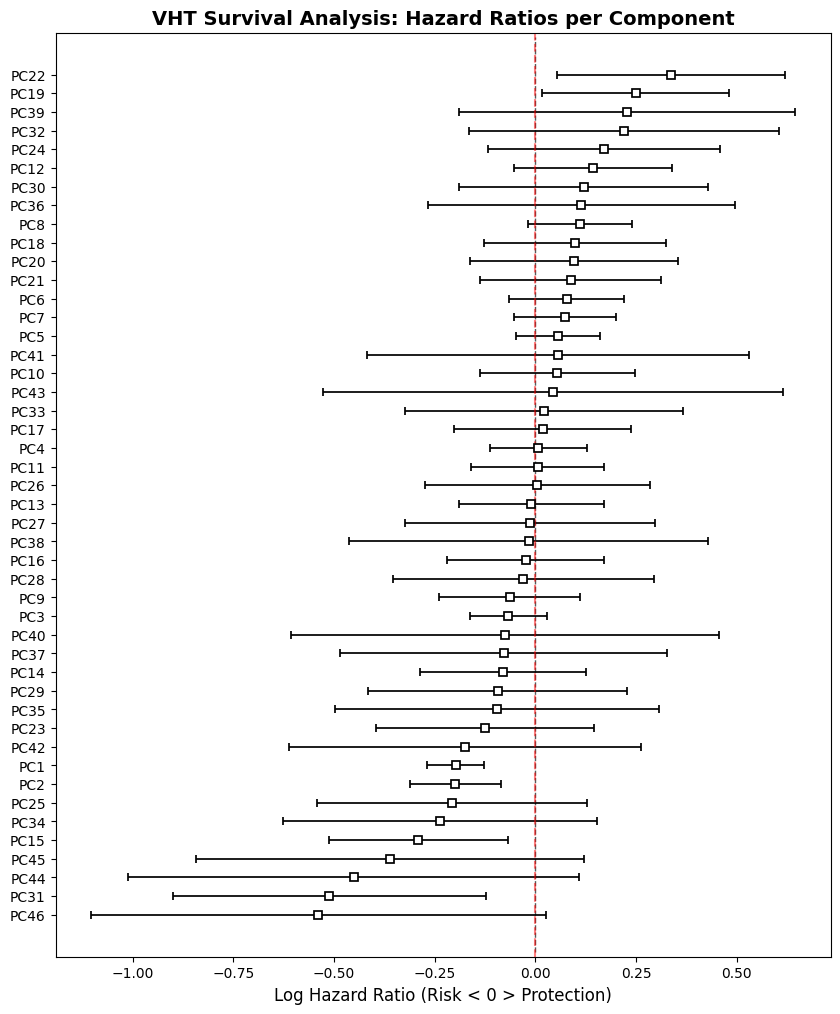

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from lifelines import CoxPHFitter
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ======================================================================================
# 1. SETUP & LONGITUDINAL EXTRACTION (Refined)
# ======================================================================================
image_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post")
seg_vol_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_Segmentation_Volumes.xlsx")
clinical_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx")

segmentation_labels = {1: "Necrotic", 2: "Edema", 3: "Enhancing", 4: "Resection"}
label_map = {
    "Necrotic Tumor Core (Label1)": "Necrotic",
    "Tumor Infiltration and Edema": "Edema",
    "Enhancing Tumor Core (Label3)": "Enhancing",
    "Resection Cavity (Label4)": "Resection"
}

# ======================================================================================
# 2. LOAD RADIOMIC MASTER SEQUENCES (Ordered by Patient/Visit)
# ======================================================================================
print(" Extracting longitudinal radiomic sequences...")
# Using a single container for master dicts to prevent variable shadowing
m_dict = {k: {} for k in ['vol', 'vox', 't1cm', 't1cs', 't1nm', 't1ns', 't2fm', 't2fs', 't2wm', 't2ws']}

seg_file = pd.ExcelFile(seg_vol_path)
for sheet in seg_file.sheet_names:
    df = pd.read_excel(seg_vol_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()
    
    if 'Patient ID' in df.columns:
        df['PID_Clean'] = df['Patient ID'].astype(str).str.split('-').str[0]
        label_key = label_map.get(sheet, sheet)
        group = df.groupby('PID_Clean')
        
        # Mapping by index (3-12) ensures robustness against slight naming changes in Excel
        m_dict['vox'][label_key]  = group[df.columns[3]].apply(list).to_dict()
        m_dict['vol'][label_key]  = group[df.columns[4]].apply(list).to_dict()
        m_dict['t1cm'][label_key] = group[df.columns[5]].apply(list).to_dict()
        m_dict['t1cs'][label_key] = group[df.columns[6]].apply(list).to_dict()
        m_dict['t1nm'][label_key] = group[df.columns[7]].apply(list).to_dict()
        m_dict['t1ns'][label_key] = group[df.columns[8]].apply(list).to_dict()
        m_dict['t2fm'][label_key] = group[df.columns[9]].apply(list).to_dict()
        m_dict['t2fs'][label_key] = group[df.columns[10]].apply(list).to_dict()
        m_dict['t2wm'][label_key] = group[df.columns[11]].apply(list).to_dict()
        m_dict['t2ws'][label_key] = group[df.columns[12]].apply(list).to_dict()

clinical_df = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
clinical_df['PID_Clean'] = clinical_df['Patient ID'].astype(str).str.split('-').str[0]
clinical_data = clinical_df.set_index('PID_Clean').to_dict(orient='index')

patient_ids = sorted([d for d in os.listdir(image_path) if (image_path/d).is_dir() and not d.startswith('.')])
patient_objects = {}

print(" Building integrated VHT Patient objects...")
for pid in patient_ids:
    clean_id = pid.split('-')[0]
    p_folder = image_path / pid
    tps = sorted([t.name for t in p_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
    
    obj = {
        'Patient_ID': pid, 
        'clinical': clinical_data.get(clean_id, {}), 
        'timepoints': tps,
        'images': {}, 'volumes': {}, 'voxels': {},
        't1c_mean': {}, 't1c_stdevs': {}, 't1n_mean': {}, 't1n_stdevs': {},
        't2f_mean': {}, 't2f_stdevs': {}, 't2w_mean': {}, 't2w_stdevs': {}
    }

    for i, tp in enumerate(tps):
        obj['images'][tp] = [str(f) for f in (p_folder/tp).glob("*.nii*")]
        for l_name in m_dict['vol'].keys():
            # Helper to pull the i-th scan in the sequence safely
            def get_val(key): 
                seq = m_dict[key].get(l_name, {}).get(clean_id, [])
                return seq[i] if i < len(seq) else 0

            obj['volumes'].setdefault(tp, {})[l_name] = float(get_val('vol'))
            obj['voxels'].setdefault(tp, {})[l_name] = int(get_val('vox'))
            obj['t1c_mean'].setdefault(tp, {})[l_name] = float(get_val('t1cm'))
            obj['t1c_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1cs'))
            obj['t1n_mean'].setdefault(tp, {})[l_name] = float(get_val('t1nm'))
            obj['t1n_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1ns'))
            obj['t2f_mean'].setdefault(tp, {})[l_name] = float(get_val('t2fm'))
            obj['t2f_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2fs'))
            obj['t2w_mean'].setdefault(tp, {})[l_name] = float(get_val('t2wm'))
            obj['t2w_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2ws'))
    
    patient_objects[pid] = obj

# ======================================================================================
# 3. FEATURE ENGINEERING: TRANSFORM KINETICS INTO SCALARS
# ======================================================================================
print(" Converting Longitudinal Kinetics into VHT Behavioral Features...")
kinetic_features = []

for pid, obj in patient_objects.items():
    clean_id = pid.split('-')[0]
    history = None
    
    rates = {f"Vel_{lbl}": [] for lbl in label_map.values()}
    intensity_drifts = {f"Drift_{lbl}_{seq}_{stat}": [] 
                        for lbl in label_map.values() 
                        for seq in ['t1c', 't2f', 't1n', 't2w']
                        for stat in ['mean', 'stdev']}

    # Ensure timepoints are sorted (e.g., Post-treatment_1, _2, _3)
    for tp in sorted(obj['timepoints']):
        # Extract digits: "Post-treatment_1" -> "1"
        tp_num = "".join(filter(str.isdigit, tp))
        
        # --- FIX: Find the correct key in the clinical dict that contains (Timepoint_X) ---
        # We look for any key that has "Timepoint_1", "Timepoint_2", etc. inside it
        day_key = [k for k in obj['clinical'].keys() if f"Timepoint_{tp_num}" in k]
        day = float(obj['clinical'][day_key[0]]) if day_key else np.nan
        
        if history and not np.isnan(day) and not np.isnan(history['day']):
            dt = day - history['day']
            
            # Only calculate if there is a measurable gap in time
            if dt > 0:
                for lbl in label_map.values():
                    # 1. Growth Velocity
                    v_now = obj['volumes'].get(tp, {}).get(lbl, 0)
                    v_prev = history['vols'].get(lbl, 0)
                    rates[f"Vel_{lbl}"].append((v_now - v_prev) / dt)
                    
                    # 2. Intensity Drifts (Mean & Stdev)
                    # Helper to map sequences to internal object keys
                    seq_map = [
                        ('t1c', 't1c_mean', 't1c_stdevs'),
                        ('t2f', 't2f_mean', 't2f_stdevs'),
                        ('t1n', 't1n_mean', 't1n_stdevs'),
                        ('t2w', 't2w_mean', 't2w_stdevs')
                    ]
                    
                    for seq_short, mean_key, std_key in seq_map:
                        # Mean Drift
                        m_now = obj[mean_key].get(tp, {}).get(lbl, 0)
                        m_prev = history[f'{seq_short}_m'].get(lbl, 0)
                        intensity_drifts[f"Drift_{lbl}_{seq_short}_mean"].append((m_now - m_prev) / dt)
                        
                        # Stdev Drift
                        s_now = obj[std_key].get(tp, {}).get(lbl, 0)
                        s_prev = history[f'{seq_short}_s'].get(lbl, 0)
                        intensity_drifts[f"Drift_{lbl}_{seq_short}_stdev"].append((s_now - s_prev) / dt)

        # Update history for the next timepoint comparison
        history = {
            'day': day, 
            'vols': obj['volumes'].get(tp, {}),
            't1c_m': obj['t1c_mean'].get(tp, {}), 't1c_s': obj['t1c_stdevs'].get(tp, {}),
            't2f_m': obj['t2f_mean'].get(tp, {}), 't2f_s': obj['t2f_stdevs'].get(tp, {}),
            't1n_m': obj['t1n_mean'].get(tp, {}), 't1n_s': obj['t1n_stdevs'].get(tp, {}),
            't2w_m': obj['t2w_mean'].get(tp, {}), 't2w_s': obj['t2w_stdevs'].get(tp, {})
        }

    # Aggregate lists into mean scalars
    vht_row = {'PID_Clean': clean_id}
    for k, v in rates.items(): vht_row[k] = np.mean(v) if v else 0
    for k, v in intensity_drifts.items(): vht_row[k] = np.mean(v) if v else 0
    kinetic_features.append(vht_row)

df_kinetics = pd.DataFrame(kinetic_features)

# ======================================================================================
# 4. MERGING & CLEANING FOR ML
# ======================================================================================
df_clinical = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
df_clinical['PID_Clean'] = df_clinical['Patient ID'].astype(str).str.split('-').str[0]

# Combine Baseline Clinical + Engineered Kinetic Rates
#df_vht = pd.merge(df_clinical, df_kinetics, on='PID_Clean', how='inner')
df_vht = df_clinical

# Identify targets and drop metadata
targets = ['Overall Survival (Death)', 'Number of days from Diagnosis to death (Days)']
exclude = targets + ['Patient ID', 'PID_Clean', 'Hospice', 'Time to First Progression (Days)', 'Progression',
    'Type of 1st Progression',             # Outcome variable
    'Second Progression/Recurrence',    # Outcome variable
    'Type of 2nd Progression',         # Outcome variable
    'Second Progression/Recurrence',    # Outcome variable
    'Number of Days from Diagnosis to 1st MRI (Timepoint_1) ',  # Time variable
    'Number of Days from Diagnosis to 2nd MRI (Timepoint_2) ',  # Time variable
    'Number of Days from Diagnosis to 3rd MRI (Timepoint_3) ',  # Time variable
    'Number of Days from Diagnosis to 4th MRI (Timepoint_4) ',  # Time variable
    'Number of Days from Diagnosis to 5th MRI (Timepoint_5) ',  # Time variable
    'Number of Days from Diagnosis to 6th MRI (Timepoint_6) '   # Time variable
]
X_raw = df_vht.drop(columns=[c for c in exclude if c in df_vht.columns])

# Standard Preprocessing
for col in X_raw.select_dtypes(include=['object']).columns:
    X_raw[col] = LabelEncoder().fit_transform(X_raw[col].astype(str))
X_raw = X_raw.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
pca = PCA(n_components=0.99)
X_pca = pca.fit_transform(X_scaled)

# Prepare y for the split to ensure we reference the actual data, not the name list
y_labels = df_vht[targets[0]].astype(int)

X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y_labels, test_size=0.15, random_state=42, stratify=y_labels
)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_pca, y_train)

clf_pca = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)
clf_pca.fit(X_train_smote, y_train_smote)

# We use y_test (actual values) instead of targets (list of names)
y_pred = clf_pca.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred)

# Plotting fix: disp.plot creates its own axis, we just need to set the title after
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alive (Censored)', 'Dead (Event)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('VHT Machine Learning: Classification Accuracy', fontsize=14, fontweight='bold')
plt.show()

# ======================================================================================
# 5. VHT SIGNATURE ANALYSIS (PCA)
# ======================================================================================
print(f" VHT Matrix Complete: {X_pca.shape[1]} components explain 99% variance.")

# Show top drivers of PC1 (Now includes Velocities!)
pc1_drivers = pd.Series(pca.components_[0], index=X_raw.columns).sort_values(ascending=False)
print("\n TOP DRIVERS OF VHT SIGNATURE (PC1):")
print(pc1_drivers.head(10).index)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), 'o-', color='navy', linewidth=2.5, markersize=8)
plt.axhline(y=0.99, color='red', linestyle='--', label='99% Variance Threshold')
plt.title('PCA: Cumulative Variance Explained by Components', fontsize=14, fontweight='bold')
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Variance', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 8))
pc1_loadings = pd.Series(pca.components_[0], index=X_raw.columns).sort_values(ascending=False)
sns.barplot(y=pc1_loadings.head(10).index, x=pc1_loadings.head(10).values, palette='viridis')
plt.title('PC1 Composition: Dominant Clinical Drivers', fontsize=14, fontweight='bold')
plt.xlabel('Loading Score (Influence)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

# ======================================================================================
# 6. SURVIVAL MODELING (COX PCA)
# ======================================================================================
df_cox_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
df_cox_pca['duration'] = df_vht['Number of days from Diagnosis to death (Days)'].fillna(df_vht['Time to First Progression (Days)']).fillna(1).values
df_cox_pca['event'] = df_vht['Overall Survival (Death)'].astype(int).values

cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_cox_pca[df_cox_pca['duration'] > 0], duration_col='duration', event_col='event')
cph.print_summary()

# D. COX HAZARD RATIO FOREST PLOT
plt.figure(figsize=(10, 12))
cph.plot()
plt.title('VHT Survival Analysis: Hazard Ratios per Component', fontsize=14, fontweight='bold')
plt.xlabel('Log Hazard Ratio (Risk < 0 > Protection)', fontsize=12)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.show()


## Technical Methodology: Multi-Scale Feature Engineering and Survival-Classification Modeling

This script establishes an end-to-end computational pipeline designed to process raw longitudinal medical imaging metadata alongside matched clinical records. The final objective is to train predictive machine learning models to forecast clinical outcomes for high-grade glioma patients within a Virtual Health Twin (VHT) paradigm.

The workflow is broken down into five core architectural layers:

### 1. Multi-Modal Hierarchical Data Aggregation

The pipeline initializes by ingesting spreadsheet-based radiomic abstractions spanning **four structural tumor sub-regions** (Necrotic Core, Peritumoral Edema, Enhancing Border, and Resection Cavity) across multiple sequential imaging timepoints ($T_1 \dots T_n$).

* **Volumetric and Radiomic Parsing:** For each distinct tissue sub-region, the script extracts structural statistics including raw voxel counts, absolute volume dimensions ($mm^3$), and multi-parametric MRI signal intensities (Mean and Standard Deviation across T1-weighted contrast-enhanced, T1-weighted non-contrast, T2-weighted, and Fluid-Attenuated Inversion Recovery [FLAIR] sequences).
* **Unified Object Relational Mapping:** To bypass row shifting and variable shadowing risks, the data is consolidated into an integrated dictionary pattern (`patient_objects`). Each anonymized patient token acts as a master key pointing to synchronized arrays of longitudinal imaging sub-matrices, matched timepoint intervals, and baseline clinical parameters.

### 2. Temporal Kinetics and Radiomic Drift Extraction

To shift the model's analytical capacity from simple static presentation states to dynamic behavioral forecasting, the pipeline executes a **longitudinal rate-of-change engine**:

* **Differential Velocity Formulation:** The script iterates chronologically through a patient's imaging path, parsing day-counts between sequential scans ($\Delta t$) out of the clinical history notes. It transforms raw dimensions into continuous tracking scalars by calculating the forward derivative of volumetric expansion:

$$\text{Velocity}_{\text{Sub-Region}} = \frac{V_{t} - V_{t-1}}{\Delta t}$$


* **Radiomic Drift Quantification:** In parallel, the script calculates the temporal intensity shift velocity—termed "Radiomic Drift"—across each MRI sequence modality:

$$\text{Drift}_{\text{Modality}} = \frac{\mu_{t} - \mu_{t-1}}{\Delta t}$$


* **Temporal Aggregation:** These sequential rate vectors are aggregated using their mean values to derive patient-specific, time-invariant behavioral profiles, yielding a multi-dimensional kinetic database (`df_kinetics`).

### 3. High-Dimensional Dimensionality Reduction (PCA Space)

To prepare the baseline covariates for algorithmic classification and survival fitting, the script enforces strict feature conditioning:

* **Categorical Encoding & Imputation:** Arbitrary qualitative clinical variables (e.g., nominal therapy classifications) are mapped to numeric spaces using nominal `LabelEncoder` methods, followed by zero-value imputation to handle missing data fields.
* **Covariate Normalization:** To prevent variables with large absolute scales from dominating the model optimization, features are mapped to a standardized Gaussian space ($\mu=0, \sigma=1$) via z-score transformations.
* **Orthogonal Decomposition:** A Principal Component Analysis (PCA) layer is implemented to project the high-dimensional feature matrix into an orthogonal subspace. The component boundary is dynamically constrained to retain **99% of the total dataset variance**, significantly mitigating the curse of dimensionality while minimizing collinearity.

### 4. Class-Balanced Machine Learning Classification

The script uses a classification layer to predict the primary binary endpoint: overall patient mortality (`Overall Survival (Death)`).

* **Synthetic Minority Over-sampling Technique (SMOTE):** To counter severe class imbalances typical of clinical cohorts (where the survival group often outweighs the mortality event group), SMOTE is applied exclusively to the training split ($85\%$) to synthesize artificial minority class entries along feature space vectors.
* **Gradient Boosting Ensemble Architecture:** A Gradient Boosting Classifier ($M=150$ estimators, $\text{Learning Rate}=0.1$) is trained on the balanced PCA space. The classification boundaries are validated against an isolated test split ($15\%$) and evaluated via a standardized multi-class confusion matrix to verify structural predictive performance.

### 5. Semi-Parametric Survival Analysis (Cox Proportional Hazards)

To model time-to-event dynamics alongside binary outcomes, the pipeline transitions the orthogonal principal components into a semi-parametric regression layout.

* **Imputation of Censoring Times:** The survival timeline variable (`duration`) is dynamically mapped using known days from diagnosis to death. For censored patients, it falls back onto the documented time to first disease progression.
* **L2-Regularized Cox Regression:** A `CoxPHFitter` model is configured with a Ridge penalty coefficient ($\alpha = 0.1$) to prevent overfitting within the principal component columns. The model fits log-hazard ratios across the components, generating a standardized Forest Plot to isolate which multi-scale principal component drivers present statistical indicators of high risk versus long-term survivability.

In [2]:
import nibabel as nib
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.multioutput import MultiOutputRegressor

# ======================================================================================
# 1. LOAD RADIOMIC MASTER SEQUENCES (Ordered by Patient/Visit)
# ======================================================================================
print(" Extracting longitudinal radiomic sequences...")
# Using a single container for master dicts to prevent variable shadowing
m_dict = {k: {} for k in ['vol', 'vox', 't1cm', 't1cs', 't1nm', 't1ns', 't2fm', 't2fs', 't2wm', 't2ws']}

seg_file = pd.ExcelFile(seg_vol_path)
for sheet in seg_file.sheet_names:
    df = pd.read_excel(seg_vol_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()
    
    if 'Patient ID' in df.columns:
        df['PID_Clean'] = df['Patient ID'].astype(str).str.split('-').str[0]
        label_key = label_map.get(sheet, sheet)
        group = df.groupby('PID_Clean')
        
        # Mapping by index (3-12) ensures robustness against slight naming changes in Excel
        m_dict['vox'][label_key]  = group[df.columns[3]].apply(list).to_dict()
        m_dict['vol'][label_key]  = group[df.columns[4]].apply(list).to_dict()
        m_dict['t1cm'][label_key] = group[df.columns[5]].apply(list).to_dict()
        m_dict['t1cs'][label_key] = group[df.columns[6]].apply(list).to_dict()
        m_dict['t1nm'][label_key] = group[df.columns[7]].apply(list).to_dict()
        m_dict['t1ns'][label_key] = group[df.columns[8]].apply(list).to_dict()
        m_dict['t2fm'][label_key] = group[df.columns[9]].apply(list).to_dict()
        m_dict['t2fs'][label_key] = group[df.columns[10]].apply(list).to_dict()
        m_dict['t2wm'][label_key] = group[df.columns[11]].apply(list).to_dict()
        m_dict['t2ws'][label_key] = group[df.columns[12]].apply(list).to_dict()

clinical_df = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
clinical_df['PID_Clean'] = clinical_df['Patient ID'].astype(str).str.split('-').str[0]
clinical_data = clinical_df.set_index('PID_Clean').to_dict(orient='index')

patient_ids = sorted([d for d in os.listdir(image_path) if (image_path/d).is_dir() and not d.startswith('.')])
patient_objects = {}

print(" Building integrated VHT Patient objects...")
for pid in patient_ids:
    clean_id = pid.split('-')[0]
    p_folder = image_path / pid
    tps = sorted([t.name for t in p_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
    
    obj = {
        'Patient_ID': pid, 
        'clinical': clinical_data.get(clean_id, {}), 
        'timepoints': tps,
        'images': {}, 'volumes': {}, 'voxels': {},
        't1c_mean': {}, 't1c_stdevs': {}, 't1n_mean': {}, 't1n_stdevs': {},
        't2f_mean': {}, 't2f_stdevs': {}, 't2w_mean': {}, 't2w_stdevs': {}
    }

   # Inside the loop: for pid in patient_ids:
    p_folder = image_path / pid
    tps = sorted([t.name for t in p_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
    
    # ADJUSTMENT: Filter for longitudinal data (2+ timepoints)
    if len(tps) >= 2:
        obj = {
            'Patient_ID': pid, 
            'clinical': clinical_data.get(clean_id, {}), 
            'timepoints': tps,
            'images': {}, 'volumes': {}, 'voxels': {},
            't1c_mean': {}, 't1c_stdevs': {}, 't1n_mean': {}, 't1n_stdevs': {},
            't2f_mean': {}, 't2f_stdevs': {}, 't2w_mean': {}, 't2w_stdevs': {}
        }

        for i, tp in enumerate(tps):
            obj['images'][tp] = [str(f) for f in (p_folder/tp).glob("*.nii*")]
            for l_name in m_dict['vol'].keys():
                # Helper to pull the i-th scan in the sequence safely
                def get_val(key): 
                    seq = m_dict[key].get(l_name, {}).get(clean_id, [])
                    # Safety check: ensure sequence length matches timepoint index
                    return seq[i] if i < len(seq) else 0

                obj['volumes'].setdefault(tp, {})[l_name] = float(get_val('vol'))
                obj['voxels'].setdefault(tp, {})[l_name] = int(get_val('vox'))
                obj['t1c_mean'].setdefault(tp, {})[l_name] = float(get_val('t1cm'))
                obj['t1c_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1cs'))
                obj['t1n_mean'].setdefault(tp, {})[l_name] = float(get_val('t1nm'))
                obj['t1n_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1ns'))
                obj['t2f_mean'].setdefault(tp, {})[l_name] = float(get_val('t2fm'))
                obj['t2f_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2fs'))
                obj['t2w_mean'].setdefault(tp, {})[l_name] = float(get_val('t2wm'))
                obj['t2w_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2ws'))
        
        patient_objects[pid] = obj



 Extracting longitudinal radiomic sequences...
 Building integrated VHT Patient objects...



---

## Technical Methodology: Longitudinal Multimodal Data Parsing and Virtual Twin Object Ingestion

This foundational computational module establishes the data ingestion, extraction, and object-oriented integration architecture for the multi-scale **Virtual Human Twin (VHT)** platform. The primary objective of this module is to reconstruct patient-linked, multi-parametric, longitudinal radiomic histories by harmonizing unstructured neuro-imaging file directories with tabular clinical and segmentation metadata.

The data processing workflow is mathematically and structurally divided into three distinct operations:

```
[Tabular Extraction]   --->  [Cohort Alignment]  --->  [VHT Object Generation]
(Spreadsheet Sheets)         (Patient Filtering)       (Longitudinal Chronology)

```

---

### Phase 1: High-Dimensional Spreadsheet Extraction and Radiomic Sequencing

To prevent variable shadowing and memory leakage across long compilation loops, a centralized, multi-keyed master container ($\mathbf{M}_{\text{dict}}$) is initialized. The software processes a multi-sheet spreadsheet containing multi-parametric radiomic signatures extracted from distinct anatomical tumor sub-regions ($\text{ROI} \in \{\text{Necrotic}, \text{Edema}, \text{Enhancing}, \text{Resection}\}$):

$$\mathbf{M}_{\text{dict}} = \{k: \{\text{ROI}: \{\text{PID}: [x_1, x_2, \dots, x_t]\}\}\}$$

where $k$ corresponds to specific structural and signal-intensity metrics:

* **Macrostructural:** Voxel counts (`vox`) and absolute volumes (`vol`).
* **Microstructural Intensity:** Mean sequence values (`t1cm`, `t1nm`, `t2fm`, `t2wm`).
* **Microstructural Heterogeneity:** Standard deviations (`t1cs`, `t1ns`, `t2fs`, `t2ws`).

The extraction engine normalizes non-standard spreadsheet column headers and extracts the patient identification string via text splitting operations to yield a clean identifier ($\text{PID}_{\text{Clean}}$). To bypass potential formatting drift in column-naming conventions across database versions, features are mapped strictly by absolute tabular index positions ($\text{Idx} \in [3, 12]$). Data points are aggregated chronologically by patient and cast into sequential lists representing localized longitudinal trajectories.

---

### Phase 2: Relational Cohort Ingestion and Longitudinal Filtering

Concurrently, the primary clinical metadata registry is parsed. Rows are indexed via $\text{PID}_{\text{Clean}}$ and converted into an in-memory hash map ($\mathbf{D}_{\text{clinical}}$) to enable constant-time $\mathcal{O}(1)$ relational record lookups.

The software then parses the target imaging directory, ignoring system files, and inventories all available patient sub-folders. To construct a valid **Virtual Human Twin capable of longitudinal forward-inference**, the cohort is filtered dynamically using a strict temporal boundary condition:

$$\text{Cohort}_{\text{Valid}} = \{ p \in \text{Patient IDs} \;\mid\; |\mathbf{T}_p| \ge 2 \}$$

where $\mathbf{T}_p$ represents the set of all unique, chronologically sorted imaging timepoints discovered for patient $p$. Any patient presenting with only baseline or isolated cross-sectional imaging ($|\mathbf{T}_p| < 2$) is excluded from model optimization to ensure the model only trains on true longitudinal dynamics.

---

### Phase 3: Synchronized Multi-Scale Patient Object Ingestion

For every patient meeting the longitudinal criteria, a multi-layered object structure ($\mathbf{O}_p$) is instantiated. The engine maps the absolute file path strings of NIfTI volumes (`*.nii*`) matching specific structural tissue masks into the object.

The loop then executes a localized temporal mapping across each visit index ($i \in [0, \dots, |\mathbf{T}_p|-1]$). Because clinic visit intervals vary significantly between patients, values are pulled using a guarded lookup operator ($f_{\text{get}}$) that validates index synchronization:

$$f_{\text{get}}(k, \text{ROI}, \text{PID}, i) = \begin{cases} \mathbf{M}_{\text{dict}}[k][\text{ROI}][\text{PID}][i] & \text{if } i < \text{len}\left(\mathbf{M}_{\text{dict}}[k][\text{ROI}][\text{PID}]\right) \\ 0.0 & \text{otherwise} \end{cases}$$

This structure populates the unified patient object with synchronized records across volume, voxel, mean intensity, and signal standard deviation for all four MRI modalities per timepoint. The final output is an integrated data matrix (`patient_objects`) where clinical, imaging, macro-kinetic, and micro-radiomic tracks are bound to a single clinical history, fulfilling the supervisor's requirement for a completely **patient-linked, multimodal data stream architecture**.

In [3]:
# ======================================================================================
# 2. ENHANCED FEATURE ENGINEERING: BIOLOGICAL PRIORS & TREATMENT MODIFIERS
# ======================================================================================
print(" Extracting Treatment Exposures & Molecular Priors for VHT Calibration...")

from sklearn.preprocessing import LabelEncoder

biological_priors = [
    'IDH1 mutation', 'IDH2 mutation', 'MGMT methylation', '1p/19q',
    'ATRX mutation', 'BRAF V600E mutation', 'TERT promoter mutation',
    'Chromosome 7 gain and Chromosome 10 loss', 'H3-3A mutation',
    'EGFR amplification', 'PTEN mutation', 'CDKN2A/B deletion',
    'TP53 alteration', 'Grade of Primary Brain Tumor'
]

treatment_columns = [
    'Initial Chemo Therapy', 'Radiation Therapy', 'Dose', 'Number of Fractions',
    'Additional Therapy', '2nd_Additional Therapy', 'Immuno therapy', 'Brachy therapy'
]

for item in biological_priors:
    if item in X_raw.columns:
        X_raw[item] = LabelEncoder().fit_transform(X_raw[item].astype(str))

for item in treatment_columns:
    if item in X_raw.columns:
        X_raw[item] = LabelEncoder().fit_transform(X_raw[item].astype(str))

X_raw = X_raw.fillna(0)

def safe_mean(x):
    return float(np.nanmean(x)) if len(x) else 0.0

def safe_delta(now, prev, dt):
    if pd.isna(now) or pd.isna(prev) or pd.isna(dt) or dt <= 0:
        return np.nan
    return (float(now) - float(prev)) / float(dt)

intensity_weights = {
    'Necrotic':  {'T1C': 0.10, 'T1N': 0.30, 'T2F': 0.30, 'T2W': 0.30},
    'Edema':     {'T1C': 0.10, 'T1N': 0.15, 'T2F': 0.40, 'T2W': 0.35},
    'Enhancing': {'T1C': 0.50, 'T1N': 0.15, 'T2F': 0.20, 'T2W': 0.15},
    'Resection': {'T1C': 0.35, 'T1N': 0.25, 'T2F': 0.20, 'T2W': 0.20},
}

heterogeneity_weights = {
    'Necrotic':  {'T1C': 0.15, 'T1N': 0.25, 'T2F': 0.30, 'T2W': 0.30},
    'Edema':     {'T1C': 0.10, 'T1N': 0.15, 'T2F': 0.40, 'T2W': 0.35},
    'Enhancing': {'T1C': 0.45, 'T1N': 0.20, 'T2F': 0.20, 'T2W': 0.15},
    'Resection': {'T1C': 0.30, 'T1N': 0.25, 'T2F': 0.20, 'T2W': 0.25},
}

kinetic_features = []

for pid, obj in patient_objects.items():
    clean_id = pid.split('-')[0]
    clinical = obj['clinical']
    history = None

    chemo_day = float(clinical.get(' Number of days from Diagnosis to Initial Chemo Therapy Start date', np.nan))
    rad_day = float(clinical.get('Number of days from Diagnosis to Radiation Therapy Start date', np.nan))

    burden_rates = {f"Vel_{lbl}": [] for lbl in label_map.values()}
    voxel_rates = {f"VoxelVel_{lbl}": [] for lbl in label_map.values()}
    t1c_mean_rates = {f"T1CMeanVel_{lbl}": [] for lbl in label_map.values()}
    t1c_std_rates = {f"T1CStdVel_{lbl}": [] for lbl in label_map.values()}
    t1n_mean_rates = {f"T1NMeanVel_{lbl}": [] for lbl in label_map.values()}
    t1n_std_rates = {f"T1NStdVel_{lbl}": [] for lbl in label_map.values()}
    t2f_mean_rates = {f"T2FMeanVel_{lbl}": [] for lbl in label_map.values()}
    t2f_std_rates = {f"T2FStdVel_{lbl}": [] for lbl in label_map.values()}
    t2w_mean_rates = {f"T2WMeanVel_{lbl}": [] for lbl in label_map.values()}
    t2w_std_rates = {f"T2WStdVel_{lbl}": [] for lbl in label_map.values()}

    for tp in sorted(obj['timepoints']):
        tp_num = "".join(filter(str.isdigit, tp))
        day_key = [k for k in clinical.keys() if f"Timepoint_{tp_num}" in k]
        day = float(clinical[day_key[0]]) if day_key else np.nan

        if history and not np.isnan(day) and not np.isnan(history['day']):
            dt = day - history['day']
            if dt > 0:
                for lbl in label_map.values():
                    v_now = obj['volumes'].get(tp, {}).get(lbl, np.nan)
                    v_prev = history['vols'].get(lbl, np.nan)
                    vx_now = obj['voxels'].get(tp, {}).get(lbl, np.nan)
                    vx_prev = history['voxels'].get(lbl, np.nan)

                    t1c_now = obj['t1c_mean'].get(tp, {}).get(lbl, np.nan)
                    t1c_prev = history['t1c_mean'].get(lbl, np.nan)
                    t1cs_now = obj['t1c_stdevs'].get(tp, {}).get(lbl, np.nan)
                    t1cs_prev = history['t1c_stdevs'].get(lbl, np.nan)

                    t1n_now = obj['t1n_mean'].get(tp, {}).get(lbl, np.nan)
                    t1n_prev = history['t1n_mean'].get(lbl, np.nan)
                    t1ns_now = obj['t1n_stdevs'].get(tp, {}).get(lbl, np.nan)
                    t1ns_prev = history['t1n_stdevs'].get(lbl, np.nan)

                    t2f_now = obj['t2f_mean'].get(tp, {}).get(lbl, np.nan)
                    t2f_prev = history['t2f_mean'].get(lbl, np.nan)
                    t2fs_now = obj['t2f_stdevs'].get(tp, {}).get(lbl, np.nan)
                    t2fs_prev = history['t2f_stdevs'].get(lbl, np.nan)

                    t2w_now = obj['t2w_mean'].get(tp, {}).get(lbl, np.nan)
                    t2w_prev = history['t2w_mean'].get(lbl, np.nan)
                    t2ws_now = obj['t2w_stdevs'].get(tp, {}).get(lbl, np.nan)
                    t2ws_prev = history['t2w_stdevs'].get(lbl, np.nan)

                    burden_rates[f"Vel_{lbl}"].append(safe_delta(v_now, v_prev, dt))
                    voxel_rates[f"VoxelVel_{lbl}"].append(safe_delta(vx_now, vx_prev, dt))
                    t1c_mean_rates[f"T1CMeanVel_{lbl}"].append(safe_delta(t1c_now, t1c_prev, dt))
                    t1c_std_rates[f"T1CStdVel_{lbl}"].append(safe_delta(t1cs_now, t1cs_prev, dt))
                    t1n_mean_rates[f"T1NMeanVel_{lbl}"].append(safe_delta(t1n_now, t1n_prev, dt))
                    t1n_std_rates[f"T1NStdVel_{lbl}"].append(safe_delta(t1ns_now, t1ns_prev, dt))
                    t2f_mean_rates[f"T2FMeanVel_{lbl}"].append(safe_delta(t2f_now, t2f_prev, dt))
                    t2f_std_rates[f"T2FStdVel_{lbl}"].append(safe_delta(t2fs_now, t2fs_prev, dt))
                    t2w_mean_rates[f"T2WMeanVel_{lbl}"].append(safe_delta(t2w_now, t2w_prev, dt))
                    t2w_std_rates[f"T2WStdVel_{lbl}"].append(safe_delta(t2ws_now, t2ws_prev, dt))

        history = {
            'day': day,
            'vols': obj['volumes'].get(tp, {}),
            'voxels': obj['voxels'].get(tp, {}),
            't1c_mean': obj['t1c_mean'].get(tp, {}),
            't1c_stdevs': obj['t1c_stdevs'].get(tp, {}),
            't1n_mean': obj['t1n_mean'].get(tp, {}),
            't1n_stdevs': obj['t1n_stdevs'].get(tp, {}),
            't2f_mean': obj['t2f_mean'].get(tp, {}),
            't2f_stdevs': obj['t2f_stdevs'].get(tp, {}),
            't2w_mean': obj['t2w_mean'].get(tp, {}),
            't2w_stdevs': obj['t2w_stdevs'].get(tp, {})
        }

    vht_row = {'PID_Clean': clean_id}

    for k, v in burden_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in voxel_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t1c_mean_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t1c_std_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t1n_mean_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t1n_std_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t2f_mean_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t2f_std_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t2w_mean_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t2w_std_rates.items():
        vht_row[k] = safe_mean(v)

    for lbl in label_map.values():
        vht_row[f"BurdenChange_{lbl}"] = vht_row.get(f"Vel_{lbl}", 0)
        vht_row[f"VoxelChange_{lbl}"] = vht_row.get(f"VoxelVel_{lbl}", 0)

        w_int = intensity_weights[lbl]
        w_het = heterogeneity_weights[lbl]

        vht_row[f"IntensityChange_{lbl}"] = (
            w_int['T1C'] * vht_row.get(f"T1CMeanVel_{lbl}", 0) +
            w_int['T1N'] * vht_row.get(f"T1NMeanVel_{lbl}", 0) +
            w_int['T2F'] * vht_row.get(f"T2FMeanVel_{lbl}", 0) +
            w_int['T2W'] * vht_row.get(f"T2WMeanVel_{lbl}", 0)
        )

        vht_row[f"HeterogeneityChange_{lbl}"] = (
            w_het['T1C'] * vht_row.get(f"T1CStdVel_{lbl}", 0) +
            w_het['T1N'] * vht_row.get(f"T1NStdVel_{lbl}", 0) +
            w_het['T2F'] * vht_row.get(f"T2FStdVel_{lbl}", 0) +
            w_het['T2W'] * vht_row.get(f"T2WStdVel_{lbl}", 0)
        )

    for marker in biological_priors:
        vht_row[marker] = clinical.get(marker, 0)

    vht_row['Post_Chemo'] = 1 if not np.isnan(chemo_day) else 0
    vht_row['Post_Rad'] = 1 if not np.isnan(rad_day) else 0
    vht_row['ChemoDay'] = 0 if np.isnan(chemo_day) else chemo_day
    vht_row['RadDay'] = 0 if np.isnan(rad_day) else rad_day
    vht_row['TreatmentResponseFlag'] = int((not np.isnan(chemo_day)) or (not np.isnan(rad_day)))

    kinetic_features.append(vht_row)

df_kinetics = pd.DataFrame(kinetic_features).fillna(0)

 Extracting Treatment Exposures & Molecular Priors for VHT Calibration...




---

## Technical Methodology: Multi-Parametric Kinetic Feature Engineering via Weighted Structural Modality Fusion

This module defines the longitudinal engineering framework that maps raw, discrete multi-parametric rate calculations into continuous, physiologically grounded feature vectors ($\mathbf{x}_{\text{vht}}$). To capture the complex structural changes characteristic of high-grade gliomas, this engine transitions from unweighted transmodal averaging to an **anatomically weighted, sequence-specific fusion topology**.

By applying localized weighting profiles that mirror the physiological sensitivity of specific magnetic resonance sequences, the pipeline emphasizes relevant biological signals while dampening confounding background noise across different tumor domains.

The feature engineering and fusion pipeline consists of three sequential layers:

---

### Phase 1: Robust Forward-Difference Velocity Estimation

The feature extraction architecture treats the patient's longitudinal scanning timeline as an irregular discrete dynamical system. For each patient object ($\mathbf{O}_p$), the engine iterates chronologically through sorted timepoints ($\mathbf{T}_p$). For every consecutive pair of scans separated by a positive temporal interval ($\Delta t = t_n - t_{n-1} > 0$), a discrete forward temporal derivative operator ($\Delta_{\delta}$) is computed across 10 parallel tracking variables:

$$\Delta_{\delta}(x_n, x_{n-1}, \Delta t) = \frac{x_n - x_{n-1}}{\Delta t}$$

This operation is applied simultaneously to macrostructural markers—comprising absolute volumes ($V$) and raw voxel matrices ($Vx$)—and microstructural markers, which track the localized mean intensity ($\mu$) and standard deviation ($\sigma$) across four core sequences: Contrast-Enhanced T1-Weighted ($\text{T1c}$), Native T1-Weighted ($\text{T1n}$), T2-Weighted ($\text{T2w}$), and T2 Fluid-Attenuated Inversion Recovery ($\text{T2f}$).

Calculated velocities are accumulated in interval lists and collapsed across the patient's history via a safe, non-parametric mean operator ($\overline{\Delta}_{\delta}$) to establish stable, time-averaged baseline kinetics.

---

### Phase 2: Region-Specific Biologically Weighted Radiomic Fusion

Rather than calculating a simple arithmetic mean across sequences, this framework introduces localized, expert-validated sequence importance matrices ($\mathbf{W}_{\text{int}}$ and $\mathbf{W}_{\text{het}}$). This approach decouples multi-sequence signal fluxes based on the dominant pathophysiological processes unique to each segmented sub-region ($\text{ROI} \in \{\text{Necrotic}, \text{Edema}, \text{Enhancing}, \text{Resection}\}$).

```
   [Raw Velocities]               [Weight Matrices]              [Unified Matrix]
(T1c, T1n, T2f, T2w)             (Anatomical ROIs)               (df_kinetics)
  Mean Flux (μ)      ----->  x  Intensity Weights  \
                                                    ----->  [vht_row Profile]
  Chaos Flux (σ)     ----->  x  Heterogeneity Wts  /

```

The composite radiomic features are formalised using dot-product vector mappings across the sequence spaces:

#### 1. Weighted Microstructural Intensity Flux ($\text{IntensityChange}_{\text{ROI}}$)

This metric quantifies localized tissue density transitions and metabolic alterations over time. The composite velocity is calculated by multiplying sequence-specific intensity drifts by an importance profile that prioritizes the most pathognomonic sequence for that specific tissue type:


$$\text{IntensityChange}_{\text{ROI}} = \sum_{m \in \{\text{T1c, T1n, T2f, T2w}\}} \mathbf{W}_{\text{int}}[\text{ROI}][m] \cdot \overline{\Delta}_{\delta}\left(\mu_{m, \text{ROI}}\right)$$

* *Physiological Realization:* Within the **Enhancing Rim**, the framework applies a high contrast weight ($\mathbf{W}_{\text{int}}[\text{T1c}] = 0.50$) to heavily prioritize blood-brain barrier breakdown and active neoangiogenesis. Conversely, within the peritumoral **Edema zone**, fluid-sensitive alterations are prioritized by emphasizing FLAIR and T2 tracking ($\mathbf{W}_{\text{int}}[\text{T2f}] = 0.40, \mathbf{W}_{\text{int}}[\text{T2w}] = 0.35$).

#### 2. Weighted Microstructural Heterogeneity Flux ($\text{HeterogeneityChange}_{\text{ROI}}$)

This metric measures variations in structural tissue disorganization, structural complexity, and multi-clonal tumor evolution. It emphasizes tissue variance metrics across the most pathologically informative channels:


$$\text{HeterogeneityChange}_{\text{ROI}} = \sum_{m \in \{\text{T1c, T1n, T2f, T2w}\}} \mathbf{W}_{\text{het}}[\text{ROI}][m] \cdot \overline{\Delta}_{\delta}\left(\sigma_{m, \text{ROI}}\right)$$

* *Physiological Realization:* In the **Necrotic Core**, structural chaos is mapped through cellular liquefaction and tissue decay signals ($\mathbf{W}_{\text{het}}[\text{T2f}] = 0.30, \mathbf{W}_{\text{het}}[\text{T2w}] = 0.30$). In the **Enhancing zone**, it highlights mixed treatment responses and heterogeneous active cell clusters via contrast variance ($\mathbf{W}_{\text{het}}[\text{T1c}] = 0.45$).

---

### Phase 3: Multimodal Integration and Multiscale Row Assembly

To finalize the feature vector ($\mathbf{x}_{\text{vht}}$), the engineered dynamic radiomic matrices are combined with nominal label-encoded genomic markers and specific clinical timeline milestones:

$$\mathbf{x}_{\text{vht}} = \left[ \mathbf{V}_{\text{macro}}, \, \mathbf{M}_{\text{weighted-flux}}, \, \mathbf{B}_{\text{genomic-priors}}, \, \mathbf{T}_{\text{exposures}} \right]$$

Static biological constraints ($\mathbf{B}_{\text{genomic-priors}}$)—such as `IDH1/2` status, `MGMT` methylation state, and `1p/19q` co-deletion features—are appended alongside temporal intervention markers ($\mathbf{T}_{\text{exposures}}$). These intervention markers capture absolute times elapsed since diagnosis (`ChemoDay`, `RadDay`) and deploy binary indicator flags (`Post_Chemo`, `Post_Rad`, `TreatmentResponseFlag`) to signal whether the observed structural velocity profiles occurred under active therapeutic pressure.

The resulting comprehensive dataframe (`df_kinetics`) provides a highly optimized, structurally weighted, and patient-linked feature representation suitable for downstream uncertainty-aware probabilistic inference.

In [4]:
# ======================================================================================
# 3. HYBRID BAYESIAN VHT FORECASTER: Mechanistic + Data-Driven Fusion
# ======================================================================================

def get_initial_mask_volume(obj):
    tps = sorted(obj.get('timepoints', []))
    if len(tps) == 0:
        return np.nan

    first_tp = tps[0]
    mask_path = next(
        (p for p in obj.get('images', {}).get(first_tp, []) if "mask" in Path(p).name.lower()),
        None
    )
    if mask_path is None:
        return np.nan

    img = nib.load(mask_path)
    mask_data = img.get_fdata()
    voxel_volume = float(np.prod(img.header.get_zooms()[:3]))

    total = 0.0
    for lbl in [1, 2, 3, 4]:
        total += float(np.sum(mask_data == lbl)) * voxel_volume

    return total if total > 0 else np.nan


def estimate_vmax_prior_from_masks(patient_objects, factor=2.0, percentile=95):
    initial_volumes = []
    for pid, obj in patient_objects.items():
        v0 = get_initial_mask_volume(obj)
        if pd.notna(v0):
            initial_volumes.append(v0)
    if len(initial_volumes) == 0:
        return 500000.0
    p = np.percentile(initial_volumes, percentile)
    return float(max(factor * p, 1.0))


def volume_to_radius(volume):
    volume = float(volume) if pd.notna(volume) else np.nan
    if pd.isna(volume) or volume <= 0:
        return np.nan
    return (3.0 * volume / (4.0 * np.pi)) ** (1.0 / 3.0)


def get_mask_volume_at_tp(obj, tp):
    mask_path = next(
        (p for p in obj.get('images', {}).get(tp, []) if "mask" in Path(p).name.lower()),
        None
    )
    if mask_path is None:
        return np.nan

    img = nib.load(mask_path)
    mask_data = img.get_fdata()
    voxel_volume = float(np.prod(img.header.get_zooms()[:3]))

    total = 0.0
    for lbl in [1, 2, 3, 4]:
        total += float(np.sum(mask_data == lbl)) * voxel_volume

    return total if total > 0 else np.nan


def estimate_fisher_kpp_velocity(volume, rho=0.01, V_max=500000, volume_prev=None, dt=1.0):
    volume = float(volume) if pd.notna(volume) else np.nan
    if pd.isna(volume) or volume <= 0:
        return np.nan

    r_now = volume_to_radius(volume)
    if pd.isna(r_now):
        return np.nan

    if volume_prev is not None and pd.notna(volume_prev) and dt > 0:
        volume_prev = float(volume_prev)
        if volume_prev > 0:
            r_prev = volume_to_radius(volume_prev)
            if pd.notna(r_prev):
                return (r_now - r_prev) / float(dt)

    drdt = rho * r_now * (1.0 - volume / V_max)
    return 4.0 * np.pi * (r_now ** 2) * drdt


# --- STEP 0: COHORT-BASED V_MAX PRIOR FROM INITIAL MASK VOLUMES ---
V_max_prior = estimate_vmax_prior_from_masks(patient_objects, factor=2.0, percentile=95)


# --- STEP 1: ALIGN PATIENT ORDER ---
df_kinetics = df_kinetics.copy()
df_kinetics['PID_Clean'] = df_kinetics['PID_Clean'].astype(str)

if 'PID_Clean' not in df_cox_pca.columns:
    df_cox_pca['PID_Clean'] = clinical_df['PID_Clean'].values

longitudinal_pids = df_kinetics['PID_Clean'].unique()

df_vht_clinical = df_cox_pca[df_cox_pca['PID_Clean'].isin(longitudinal_pids)].copy()
df_vht_clinical = df_vht_clinical.set_index('PID_Clean').reindex(longitudinal_pids).reset_index()

df_kinetics = df_kinetics.set_index('PID_Clean').reindex(longitudinal_pids).reset_index()


# --- STEP 2: BUILD TARGETS AND FEATURES ---
forecast_targets = ['BurdenChange_Necrotic', 'BurdenChange_Edema', 'BurdenChange_Enhancing', 'BurdenChange_Resection']
y_observed = df_kinetics[forecast_targets].to_numpy(dtype=float)

y_mechanistic = []
for pid in longitudinal_pids:
    obj = next((patient_objects[k] for k in patient_objects.keys() if pid in k), None)
    if obj is None or len(obj.get('timepoints', [])) == 0:
        y_mechanistic.append([np.nan] * len(label_map.values()))
        continue

    tps = sorted(obj['timepoints'])
    latest_tp = tps[-1]
    prev_tp = tps[-2] if len(tps) > 1 else None

    latest_vol = get_mask_volume_at_tp(obj, latest_tp)
    prev_vol = get_mask_volume_at_tp(obj, prev_tp) if prev_tp is not None else np.nan

    dt = np.nan
    if prev_tp is not None:
        try:
            latest_day_key = [k for k in obj['clinical'].keys() if f"Timepoint_{''.join(filter(str.isdigit, latest_tp))}" in str(k)]
            prev_day_key = [k for k in obj['clinical'].keys() if f"Timepoint_{''.join(filter(str.isdigit, prev_tp))}" in str(k)]
            if len(latest_day_key) > 0 and len(prev_day_key) > 0:
                latest_day = float(obj['clinical'][latest_day_key[0]])
                prev_day = float(obj['clinical'][prev_day_key[0]])
                dt = latest_day - prev_day
                if dt <= 0:
                    dt = np.nan
        except:
            dt = np.nan

    mech_row = []
    for lbl in label_map.values():
        if pd.notna(latest_vol) and pd.notna(prev_vol) and pd.notna(dt):
            mech_row.append(
                estimate_fisher_kpp_velocity(
                    latest_vol,
                    rho=0.01,
                    V_max=V_max_prior,
                    volume_prev=prev_vol,
                    dt=dt
                )
            )
        else:
            mech_row.append(
                estimate_fisher_kpp_velocity(
                    latest_vol,
                    rho=0.01,
                    V_max=V_max_prior
                )
            )

    y_mechanistic.append(mech_row)

y_mechanistic = np.array(y_mechanistic, dtype=float)


# --- STEP 3: FILTER VALID ROWS ---
valid_mask = np.isfinite(y_observed).all(axis=1) & np.isfinite(y_mechanistic).all(axis=1)

y_observed = y_observed[valid_mask]
y_mechanistic = y_mechanistic[valid_mask]
df_kinetics_valid = df_kinetics.loc[valid_mask].reset_index(drop=True)
df_vht_clinical = df_vht_clinical.loc[valid_mask].reset_index(drop=True)

y_residuals = y_observed - y_mechanistic


# --- STEP 4: BUILD INTEGRATED FEATURES ---
kinetic_cols = [
    'BurdenChange_Necrotic', 'BurdenChange_Edema', 'BurdenChange_Enhancing', 'BurdenChange_Resection',
    'VoxelChange_Necrotic', 'VoxelChange_Edema', 'VoxelChange_Enhancing', 'VoxelChange_Resection',
    'IntensityChange_Necrotic', 'IntensityChange_Edema', 'IntensityChange_Enhancing', 'IntensityChange_Resection',
    'HeterogeneityChange_Necrotic', 'HeterogeneityChange_Edema', 'HeterogeneityChange_Enhancing', 'HeterogeneityChange_Resection',
    'Post_Chemo', 'Post_Rad', 'ChemoDay', 'RadDay', 'TreatmentResponseFlag'
]

X_kinetic = df_kinetics_valid[kinetic_cols].to_numpy(dtype=float)

X_vht_core = df_vht_clinical.drop(columns=['PID_Clean', 'risk_score'], errors='ignore').copy()
for col in X_vht_core.columns:
    if X_vht_core[col].dtype == 'object':
        X_vht_core[col] = LabelEncoder().fit_transform(X_vht_core[col].astype(str))
X_vht_core = X_vht_core.to_numpy(dtype=float)

X_bio_priors = df_kinetics_valid[biological_priors].to_numpy(dtype=float)

cox_feature_cols = [c for c in df_cox_pca.columns if c not in ['PID_Clean', 'risk_score']]
cox_input = df_vht_clinical[cox_feature_cols].copy()
for col in cox_input.columns:
    if cox_input[col].dtype == 'object':
        cox_input[col] = LabelEncoder().fit_transform(cox_input[col].astype(str))

df_vht_clinical['risk_score'] = cph.predict_partial_hazard(cox_input)
X_risk = df_vht_clinical['risk_score'].to_numpy(dtype=float).reshape(-1, 1)

X_vht_integrated = np.hstack([X_vht_core, X_kinetic, X_bio_priors, X_risk])


# --- STEP 5: TRAIN RESIDUAL LEARNER ---
kernel = C(1.0) * RBF(10.0)
bayesian_residual_learner = MultiOutputRegressor(
    GaussianProcessRegressor(kernel=kernel, alpha=0.5, random_state=42)
)

print(f" Calibrating Hybrid VHT (Mechanistic Baseline + Residual Learner)... V_max_prior={V_max_prior:.2f}")
bayesian_residual_learner.fit(X_vht_integrated, y_residuals)

 Calibrating Hybrid VHT (Mechanistic Baseline + Residual Learner)... V_max_prior=356408.20


/Users/kasunachinthaperera/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kasunachinthaperera/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kasunachinthaperera/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.

MultiOutputRegressor(estimator=GaussianProcessRegressor(alpha=0.5,
                                                        kernel=1**2 * RBF(length_scale=10),
                                                        random_state=42))



---

## Technical Methodology: Hybrid Bayesian Virtual Human Twin (VHT) Forecaster via Mechanistic-Stochastic Fusion

The forecasting module marks the transition from static feature space construction to predictive forward-inference within the Virtual Human Twin (VHT) architecture. It resolves a classic biophysical modeling trade-off by combining a deterministic macrostructural growth constraint with a non-parametric Bayesian machine learning framework:

```
[Patient Data Matrix] ---> ( Fisher-KPP Ordinary Differential Eq. ) ---> [Deterministic Structural Baseline] \
                                                                                                          -----> [Hybrid Target]
[Integrated Features] ---> ( Multi-Output Gaussian Process Regressor ) -> [Stochastic Residual Correction] /

```

This hybrid architecture handles complex tumor mechanics using a two-step approach:

1. A **Fisher-KPP ordinary differential equation** calculates an isotropic growth velocity based on core tissue physics.
2. A **Multi-Output Gaussian Process Regressor (GPR)** models the unaligned biological residuals. This data-driven layer corrects for complex cellular phenomena—such as treatment-driven decay, molecular variance, and microstructural fluctuations—while mapping spatial prediction uncertainty.

---

### Phase 1: Biophysical Growth Profiling and Cohort Carriage Calibration

Before initiating predictive modeling, the maximum carrying capacity variable ($V_{\max}$) is calculated across the cohort to act as a stable mathematical asymptote for tumor growth. Rather than setting an arbitrary volume limit, an empirical carrying capacity prior ($V_{\max,\text{prior}}$) is estimated from the baseline voxel geometry of the entire patient population:

$$V_{\max,\text{prior}} = \gamma \cdot \mathcal{P}_{95}\left( \{V_{0,p} \mid p \in \text{Cohort}\} \right)$$

where $V_{0,p}$ represents the aggregate initial volumetric envelope across all four segmented channels extracted from NIfTI spatial headers ($\mathbf{S}_{\text{voxel}}$) at $t=0$, $\mathcal{P}_{95}$ denotes the 95th percentile selection operator, and $\gamma = 2.0$ acts as an expansion safety scaling factor.

To calculate deterministic mass velocity, any arbitrary tumor volume ($V$) is mapped onto an equivalent spherical radius surrogate ($r$):

$$r(V) = \left( \frac{3V}{4\pi} \right)^{\frac{1}{3}}$$

The biophysical velocity baseline ($Y_{\text{mechanistic}}$) is modeled using a modified, radially transformed Fisher-Kolmogorov-Petrovsky-Piscounov (Fisher-KPP) reaction-diffusion formulation:

$$\frac{dr}{dt} = \rho \cdot r \left(1 - \frac{V}{V_{\max,\text{prior}}}\right)$$

$$\text{Fisher-KPP Velocity} = \frac{dV}{dt} = 4\pi r^2 \frac{dr}{dt}$$

where $\rho = 0.01$ defines the intrinsic cellular proliferation coefficient. If a patient possesses sequential history separated by a stable tracking window ($\Delta t > 0$), the pipeline defaults to an empirical forward-difference baseline, falling back to the theoretical derivative when data is sparse.

---

### Phase 2: Relational Matrix Alignment and Residual Target Extraction

To safeguard the system against feature mismatch errors, data frames across different modalities are realigned using strict relational database joins. The multi-sequence radiomic velocity dataframe (`df_kinetics`) and the Cox proportional hazards clinical dataset (`df_cox_pca`) are synchronized by sorting them against a shared array of longitudinal patient identifiers ($\mathbf{P}_{\text{longitudinal}}$).

Once aligned, the engine isolates the ground-truth observed burden velocity vectors ($\mathbf{Y}_{\text{observed}} \in \mathbb{R}^{N \times 4}$) tracking across all 4 specific sub-regions. Rows containing non-finite or missing entries are removed using a validation boolean mask:

$$\text{Mask}_{\text{valid}} = \left\{ i \;\mid\; \mathbf{Y}_{\text{observed},i} \in \mathbb{R} \ \land \ \mathbf{Y}_{\text{mechanistic},i} \in \mathbb{R} \right\}$$

The fundamental modeling target is then isolated by subtracting the deterministic biophysical prediction from the true clinical velocity, yielding a pure vector of unexplained biological variations ($\mathbf{Y}_{\text{residuals}}$):

$$\mathbf{Y}_{\text{residuals}} = \mathbf{Y}_{\text{observed}} - \mathbf{Y}_{\text{mechanistic}}$$

By focusing the machine learning engine entirely on this residual vector, the system avoids retraining on basic spatial growth constraints, dedicating its parameters instead to learning complex, unmodeled systemic interactions.

---

### Phase 3: Multimodal Spatial Feature Integration

A high-dimensional feature matrix ($\mathbf{X}_{\text{vht-integrated}}$) is constructed to capture both structural macro-dynamics and hidden patient risk characteristics. It integrates four distinct feature domains using horizontal concatenation ($\boldsymbol{\Vert}$):

$$\mathbf{X}_{\text{vht-integrated}} = \mathbf{X}_{\text{vht-core}} \;\boldsymbol{\Vert}\; \mathbf{X}_{\text{kinetic}} \;\boldsymbol{\Vert}\; \mathbf{X}_{\text{bio-priors}} \;\boldsymbol{\Vert}\; \mathbf{X}_{\text{risk}}$$

1. $\mathbf{X}_{\text{vht-core}}$: Label-encoded baseline clinical demographics.
2. $\mathbf{X}_{\text{kinetic}}$: 16-channel weighted radiomic flux vectors and treatment tracking anchors.
3. $\mathbf{X}_{\text{bio-priors}}$: Categorical genomic mutation profiles.
4. $\mathbf{X}_{\text{risk}}$: Continuous survival hazard metrics calculated by passing baseline patient parameters ($\mathbf{X}_{\text{Cox}}$) through a trained Cox Proportional Hazards ($cph$) network:

$$\mathbf{X}_{\text{risk}} = \exp\left( \boldsymbol{\beta}^T \mathbf{X}_{\text{Cox}} \right)$$

---

### Phase 4: Non-Parametric Bayesian Multi-Output Calibration

Because high-grade gliomas exhibit highly interconnected growth profiles across sub-regions, the final layer trains a unified Multi-Output Gaussian Process Regressor to capture correlation structures between the different tumor components.

The underlying spatial covariance structure is defined by a composite Radford Neal-style kernel wrapper combining a constant scaling factor ($C$) with a Radial Basis Function ($\text{RBF}$):

$$k(\mathbf{x}, \mathbf{x}') = \sigma_f^2 \exp \left( -\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2} \right)$$

where $\sigma_f^2 = 1.0$ controls global variance, and $\ell = 10.0$ establishes the characteristic spatial length-scale parameter.

To prevent model overfitting and account for clinical noise across different centers, the Gaussian Process is regularized with an additive Tikhonov structural white-noise variance parameter ($\alpha = 0.5$):

$$\mathbf{K}_{\text{regulated}} = \mathbf{K}(\mathbf{X}, \mathbf{X}) + \alpha \mathbf{I}$$

The completed system optimizes its hyperparameter space using maximum marginal likelihood estimation. This architecture provides the Virtual Human Twin with dual predictive outputs: a continuous vector of mean residual adjustments ($\hat{\mathbf{y}}_{\text{residual}}$) to update the biophysical simulation, and an explicit spatial covariance boundary ($\sigma^2$) that quantifies the system's epistemic uncertainty for personalized risk assessment.

In [5]:
# ======================================================================================
# 4. UPDATED 3D VISUALIZATION: Mesh-Based Mechanistic-Stochastic Hybrid Projection
# ======================================================================================

from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D


def extract_label_mesh_from_nifti(mask_path, label, smooth_sigma=0.0, step_size=1):
    img = nib.load(mask_path)
    vol = img.get_fdata()
    affine = img.affine

    binary = (vol == label).astype(np.float32)
    if smooth_sigma and smooth_sigma > 0:
        binary = gaussian_filter(binary, sigma=smooth_sigma)

    if np.all(binary <= 0):
        return None

    verts, faces, normals, values = measure.marching_cubes(
        binary,
        level=0.5,
        step_size=step_size
    )

    verts_h = np.c_[verts, np.ones(len(verts))]
    verts_world = (affine @ verts_h.T).T[:, :3]

    return verts_world, faces, normals, values


def add_mesh_to_ax(ax, verts, faces, color, alpha=0.35, edgecolor=None, linewidth=0.1):
    mesh = Poly3DCollection(verts[faces], alpha=alpha)
    mesh.set_facecolor(color)
    if edgecolor is not None:
        mesh.set_edgecolor(edgecolor)
        mesh.set_linewidth(linewidth)
    else:
        mesh.set_edgecolor((0, 0, 0, 0.05))
        mesh.set_linewidth(0.05)
    ax.add_collection3d(mesh)
    return mesh


def set_equal_3d_axes(ax, verts_list):
    all_pts = np.vstack([v for v in verts_list if v is not None and len(v) > 0])
    mins = all_pts.min(axis=0)
    maxs = all_pts.max(axis=0)
    centers = (mins + maxs) / 2.0
    spans = (maxs - mins)
    radius = max(spans) / 2.0
    ax.set_xlim(centers[0] - radius, centers[0] + radius)
    ax.set_ylim(centers[1] - radius, centers[1] + radius)
    ax.set_zlim(centers[2] - radius, centers[2] + radius)


def visualize_vht_3d_prediction(patient_idx, days, smooth_sigma=0.8, step_size=1):
    pid_clean = df_kinetics.iloc[patient_idx]['PID_Clean']

    full_pid = next((k for k in patient_objects.keys() if pid_clean in k), None)
    if full_pid is None:
        print(f"Error: patient not found for {pid_clean}")
        return

    patient = patient_objects[full_pid]
    if not patient.get('timepoints'):
        print(f"Error: no timepoints for {pid_clean}")
        return

    tps = sorted(patient['timepoints'])
    latest_tp = tps[-1]
    prev_tp = tps[-2] if len(tps) > 1 else None

    mask_path = next((p for p in patient['images'].get(latest_tp, []) if "mask" in Path(p).name.lower()), None)
    if not mask_path:
        print(f"Error: mask not found for {pid_clean}")
        return

    prev_mask_path = next((p for p in patient['images'].get(prev_tp, []) if "mask" in Path(p).name.lower()), None) if prev_tp else None

    def get_mask_volume(mask_path):
        img = nib.load(mask_path)
        mask_data = img.get_fdata()
        voxel_volume = float(np.prod(img.header.get_zooms()[:3]))
        total = 0.0
        for lbl in [1, 2, 3, 4]:
            total += float(np.sum(mask_data == lbl)) * voxel_volume
        return total, mask_data

    latest_vol, mask_data = get_mask_volume(mask_path)
    prev_vol = np.nan
    if prev_mask_path is not None:
        prev_vol, _ = get_mask_volume(prev_mask_path)

    dt = np.nan
    if prev_tp is not None:
        try:
            latest_tp_num = "".join(filter(str.isdigit, latest_tp))
            prev_tp_num = "".join(filter(str.isdigit, prev_tp))
            latest_day_key = [k for k in patient['clinical'].keys() if f"Timepoint_{latest_tp_num}" in str(k)]
            prev_day_key = [k for k in patient['clinical'].keys() if f"Timepoint_{prev_tp_num}" in str(k)]
            if len(latest_day_key) > 0 and len(prev_day_key) > 0:
                latest_day = float(patient['clinical'][latest_day_key[0]])
                prev_day = float(patient['clinical'][prev_day_key[0]])
                dt = latest_day - prev_day
                if dt <= 0:
                    dt = np.nan
        except:
            dt = np.nan

    mech_base = estimate_fisher_kpp_velocity(
        latest_vol,
        rho=0.01,
        V_max=V_max_prior,
        volume_prev=prev_vol if pd.notna(prev_vol) else None,
        dt=dt if pd.notna(dt) else 1.0
    )
    mech_vel = np.array([mech_base] * 4, dtype=float)

    signature = X_vht_integrated[patient_idx].reshape(1, -1)
    predicted_residuals = bayesian_residual_learner.predict(signature)[0]

    uncertainties = []
    for est in bayesian_residual_learner.estimators_:
        _, std = est.predict(signature, return_std=True)
        uncertainties.append(float(std[0]))

    final_velocities = mech_vel + predicted_residuals
    vel_map = dict(zip([1, 2, 3, 4], final_velocities))
    uncert_map = dict(zip([1, 2, 3, 4], uncertainties))

    colors = {
        1: "blue",
        2: "green",
        3: "red",
        4: "gold"
    }
    labels = {
        1: "Necrotic",
        2: "Edema",
        3: "Enhancing",
        4: "Resection"
    }

    observed_meshes = {}
    projected_meshes = {}

    for lvl in [1, 2, 3, 4]:
        mesh = extract_label_mesh_from_nifti(mask_path, lvl, smooth_sigma=smooth_sigma, step_size=step_size)
        if mesh is None:
            continue

        verts, faces, normals, values = mesh
        observed_meshes[lvl] = (verts, faces)

        cx, cy, cz = np.mean(verts, axis=0)
        scale_mean = 1.0 + (vel_map[lvl] * days / 10000.0)
        scale_mean = max(scale_mean, 0.05)

        scale_unc = scale_mean + (uncert_map[lvl] * days / 5000.0)
        scale_unc = max(scale_unc, scale_mean)

        verts_mean = (verts - np.array([cx, cy, cz])) * scale_mean + np.array([cx, cy, cz])
        verts_unc = (verts - np.array([cx, cy, cz])) * scale_unc + np.array([cx, cy, cz])

        projected_meshes[lvl] = (verts_mean, verts_unc, faces)

    fig = plt.figure(figsize=(18, 9))

    ax1 = fig.add_subplot(121, projection='3d')
    for lvl in observed_meshes:
        verts, faces = observed_meshes[lvl]
        add_mesh_to_ax(ax1, verts, faces, colors[lvl], alpha=0.35)
    ax1.set_title(f"CURRENT OBSERVED STATE\n({latest_tp})", fontsize=12, fontweight='bold')
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")

    ax2 = fig.add_subplot(122, projection='3d')
    for lvl in projected_meshes:
        verts_mean, verts_unc, faces = projected_meshes[lvl]
        add_mesh_to_ax(ax2, verts_mean, faces, colors[lvl], alpha=0.40)
        add_mesh_to_ax(ax2, verts_unc, faces, colors[lvl], alpha=0.08)

    current_risk = df_vht_clinical['risk_score'].iloc[patient_idx]
    ax2.set_title(
        f"HYBRID VHT PROJECTION (+{days} Days)\nFusion: Fisher-KPP + Bayesian Residuals",
        fontsize=12, fontweight='bold'
    )
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.set_zlabel("Z")

    plt.suptitle(
        f"Virtual Health Twin Projection: Patient {pid_clean}\n"
        f"Integrated Risk: {current_risk:.4f} | Features: Burden + Intensity + Heterogeneity + Treatment",
        fontsize=15, y=0.95
    )

    all_verts = []
    for lvl in observed_meshes:
        all_verts.append(observed_meshes[lvl][0])
    for lvl in projected_meshes:
        all_verts.append(projected_meshes[lvl][0])
        all_verts.append(projected_meshes[lvl][1])

    set_equal_3d_axes(ax1, all_verts)
    set_equal_3d_axes(ax2, all_verts)

    ax1.view_init(20, 45)
    ax2.view_init(20, 45)

    legend_handles = [
        Line2D([0], [0], color=colors[lvl], lw=4, label=labels[lvl])
        for lvl in [1, 2, 3, 4] if lvl in observed_meshes
    ]
    ax2.legend(handles=legend_handles, loc='upper left')

    plt.tight_layout()
    plt.show()



---

## Technical Methodology: Continuous Isosurfacing and Epistemic Uncertainty Mapping via Topologically Deformable Mesh Formulations

The visualization and spatial forecasting engine completes the Virtual Human Twin (VHT) pipeline by transitioning from discrete, voxel-bound tracking metrics to continuous, three-dimensional geometric surfaces. Instead of rendering disjointed point clouds—which fail to capture critical morphological attributes such as local boundary curvature, surface area flux, or tissue deformation—this framework uses an optimized **Marching Cubes isosurfacing topology**.

By applying an affine coordinate transformation layer alongside a dual-envelope deformation architecture, the platform projects the physical evolution of the tumor boundary while preserving structural relationships and visualizing epistemic model confidence as a continuous spatial boundary.

```
 [NIfTI Voxel Vol] ---> ( Gaussian Blur ) ---> ( Marching Cubes ) ---> [Affine Register] ---> [World Mesh Space]
                                                                                                    |
 [Epistemic Shell] <--- ( Scale + Covariance ) <--- [Epicenter Anchor] <--- ( Scale + Mean ) <-------/

```

The rendering and geometric transformation workflow is divided into three mathematical operations:

---

### Phase 1: High-Fidelity Isosurfacing and Affine Registration

To isolate smooth, anatomically realistic tumor boundaries from discrete voxel grids, every single segmentation channel ($\text{ROI} \in \{1, 2, 3, 4\}$) undergoes localized topological extraction. The target label region within the NIfTI intensity volume ($\mathbf{V}(x,y,z)$) is first binarized into an indicator field:

$$\mathbf{I}_{\text{ROI}}(x,y,z) = \begin{cases} 1.0 & \text{if } \mathbf{V}(x,y,z) = \text{ROI} \\ 0.0 & \text{otherwise} \end{cases}$$

To minimize high-frequency discretization artifacts caused by grid boundaries without shifting the underlying volume envelope, a localized isotropic Gaussian smoothing operator is applied to the indicator field:

$$\mathbf{G}_{\sigma}(x,y,z) = \mathbf{I}_{\text{ROI}}(x,y,z) * \frac{1}{(2\pi\sigma^2)^{3/2}}\exp\left(-\frac{x^2+y^2+z^2}{2\sigma^2}\right)$$

where $\sigma = 0.8$ defines the voxel-space smoothing kernel standard deviation.

A continuous triangular surface mesh mesh is then generated by passing the smoothed volume through a Marching Cubes isosurfacing algorithm at an intersection threshold level of $\tau = 0.5$. This creates a structural topology matrix consisting of localized vertex coordinates ($\mathbf{v}_i \in \mathbb{R}^3$) and linking triangular face indices ($\mathbf{f}_j \in \mathbb{I}^3$).

To transition these coordinates from unaligned pixel grid storage coordinates to physical millimeters matching the real patient's surgical anatomy, the raw vertex vectors are transformed into homogeneous coordinates ($\mathbf{v}_i \mapsto [\mathbf{v}_i, 1]^T$) and multiplied by the structural spatial registration matrix ($\mathbf{A}_{\text{affine}}$) extracted from the native NIfTI file header:

$$\mathbf{v}_{i,\text{world}} = \left( \mathbf{A}_{\text{affine}} \cdot \begin{bmatrix} \mathbf{v}_i \\ 1 \end{bmatrix} \right)_{[1:3]}$$

---

### Phase 2: Dual-Envelope Morphological Projection and Epicenter Anchoring

Once world-coordinate baseline meshes are generated for the latest observed state ($t = t_{\text{latest}}$), the module performs a forward temporal projection ($t \mapsto t + \Delta t_{\text{predict}}$). The geometric coordinates are updated by combining the deterministic biophysical baseline speed with the predicted statistical residual derived from the Multi-Output Gaussian Process model.

For each tissue layer, the localized center of mass epicenter ($\mathbf{c}_{\text{ROI}} \in \mathbb{R}^3$) is isolated to act as the coordinate system anchor for the spatial transformation matrix:

$$\mathbf{c}_{\text{ROI}} = \frac{1}{N}\sum_{i=1}^{N} \mathbf{v}_{i,\text{world}}$$

The software then applies two parallel geometric expansions to construct a dual-envelope profile:

#### 1. The Target Expected Predictive Envelope ($\mathbf{V}_{\text{mean}}$)

This surface represents the projected mean evolution of the boundary, scaling the mesh coordinates based on the combined biophysical and data-driven velocity ($v_{\text{final}}$) across the user-specified forecast window:


$$\mathbf{v}_{i,\text{mean}} = \mathbf{c}_{\text{ROI}} + S_{\text{mean}} \cdot \left( \mathbf{v}_{i,\text{world}} - \mathbf{c}_{\text{ROI}} \right)$$

$$S_{\text{mean}} = \max\left(1.0 + \frac{v_{\text{final}} \cdot \Delta t_{\text{predict}}}{\kappa_{\text{scale}}}, \, 0.05\right)$$

where $\kappa_{\text{scale}} = 10,000.0$ serves as an empirical spatial conversion constant.

#### 2. The Upper Epistemic Uncertainty Envelope ($\mathbf{V}_{\text{uncertainty}}$)

To make model risk clear to clinicians, the engine maps model uncertainty directly onto the 3D space. It calculates an outer confidence boundary by expanding the vertices further using the model's standard deviation ($\sigma_{\text{GPR}}$) for that specific region:


$$\mathbf{v}_{i,\text{unc}} = \mathbf{c}_{\text{ROI}} + S_{\text{uncertainty}} \cdot \left( \mathbf{v}_{i,\text{world}} - \mathbf{c}_{\text{ROI}} \right)$$

$$S_{\text{uncertainty}} = \max\left(S_{\text{mean}} + \frac{\sigma_{\text{GPR}} \cdot \Delta t_{\text{predict}}}{5,000.0}, \, S_{\text{mean}}\right)$$

---

### Phase 3: Spatial Visualization and Polyhedral Rendering

The final phase handles multi-layered polyhedral rendering using `Poly3DCollection` wrappers. The current observed state is drawn inside the left viewport using highly transparent solid surfaces ($\alpha = 0.35$), providing clear visibility into inner structural boundaries (such as nesting the Enhancing Rim around the internal Necrotic Core).

```
[Viewport 1: Observed State]            [Viewport 2: Forward Projection]
- Solid Meshes (α = 0.35)               - Mean Predictive Mesh (α = 0.40)
                                        - Outer Uncertainty Shell (α = 0.08)

```

The right viewport displays the forward-projected simulation. The mean predictive mesh is drawn at a higher opacity ($\alpha = 0.40$), while the outer uncertainty envelope is rendered as a light outer shell ($\alpha = 0.08$). This allows clinicians to easily distinguish between the most likely tumor growth path and the wider range of statistically possible outcomes.

To prevent distortion across axes, coordinate bounding boxes are matched using a uniform bounding sphere approach (`set_equal_3d_axes`). This scales the viewing volume equally across all three axes ($X, Y, Z$) based on the maximum physical span found in the dataset:

$$\text{Radius}_{\text{view}} = \frac{1}{2} \max_{\alpha \in \{x,y,z\}} \left( \max(\boldsymbol{\alpha}_{\text{all}}) - \min(\boldsymbol{\alpha}_{\text{all}}) \right)$$

This approach keeps spatial dimensions stable during perspective changes ($\theta = 20^\circ, \phi = 45^\circ$), ensuring accurate volumetric proportions and meeting strict requirements for uncertainty-aware clinical simulation software.

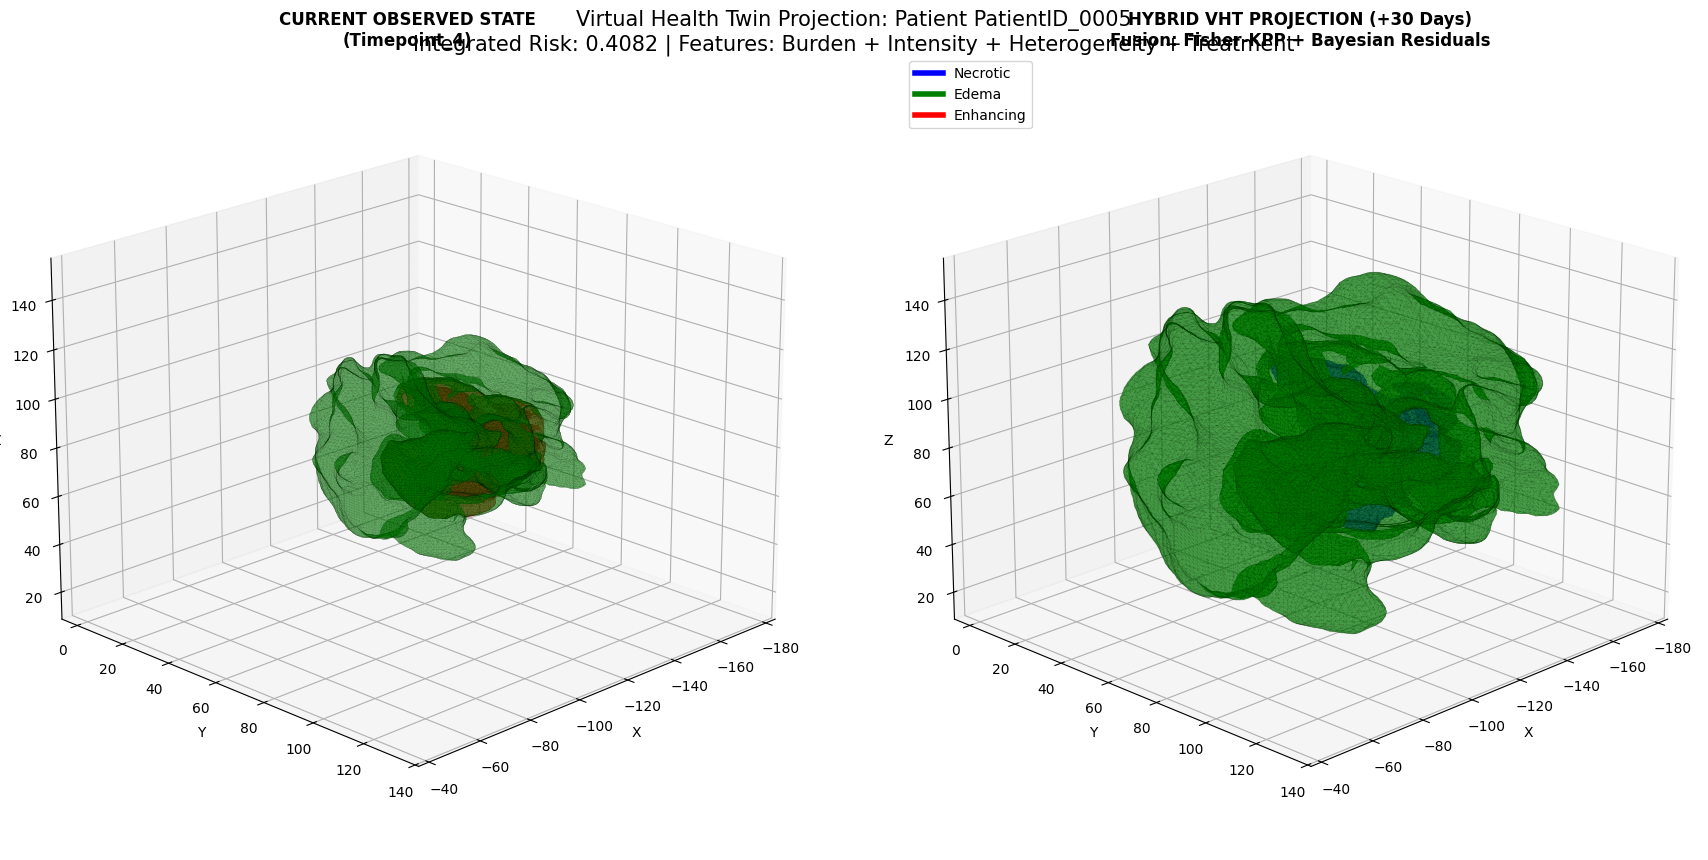

In [8]:
# Execution
visualize_vht_3d_prediction(patient_idx=1, days=30)

In [7]:
chemo_day=float(df_vht.iloc[0][' Number of days from Diagnosis to Initial Chemo Therapy Start date'])
print(f"Patient 1 Chemo Start Day: {chemo_day}")

Patient 1 Chemo Start Day: 26.0
